In [1]:
#!pip install matplotlib biopython scikit-learn numpy pandas transformers -q

In [2]:
#!pip uninstall torch torchvision torchaudio -y
#!pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.7.0+cu128
True
NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [4]:
import re
import torch
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, matthews_corrcoef, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold
import joblib
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

C:\Users\prana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def parse_fasta(filepath):
    headers, seqs = [], []
    for record in SeqIO.parse(filepath, "fasta"):
        headers.append(record.id)
        seqs.append(str(record.seq))
    return headers, seqs

signal_headers, signal_seqs = parse_fasta("Data/signal_filtered.fasta")
nonsignal_headers, nonsignal_seqs = parse_fasta("Data/nonsignal_filtered.fasta")

all_headers = signal_headers + nonsignal_headers
all_seqs    = signal_seqs + nonsignal_seqs
labels      = [1] * len(signal_seqs) + [0] * len(nonsignal_seqs)

print(f"Signal: {len(signal_seqs)}, Non-signal: {len(nonsignal_seqs)}, Total: {len(all_seqs)}")

Signal: 980, Non-signal: 950, Total: 1930


In [6]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

def get_physicochemical(seq):
    clean = ''.join([aa for aa in seq if aa in AMINO_ACIDS])
    if len(clean) < 5:
        return np.zeros(6)
    try:
        a = ProteinAnalysis(clean)
        return np.array([
            a.gravy(),
            a.isoelectric_point(),
            a.molecular_weight(),
            a.instability_index(),
            a.aromaticity(),
            a.secondary_structure_fraction()[0]
        ])
    except:
        return np.zeros(6)

physchem = np.array([get_physicochemical(s) for s in all_seqs])

scaler = StandardScaler()
physchem_scaled = scaler.fit_transform(physchem)
print("Physicochemical shape:", physchem_scaled.shape)

Physicochemical shape: (1930, 6)


In [7]:
print("Loading BioBERT...")
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")
model.eval()

bert_embeddings = []

for i, seq in enumerate(all_seqs):
    spaced_seq = ' '.join(seq[:500])
    inputs = tokenizer(spaced_seq, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :].numpy()
        bert_embeddings.append(emb[0])
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(all_seqs)} done")

bert_embeddings = np.array(bert_embeddings)
print("BioBERT shape:", bert_embeddings.shape)

Loading BioBERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 41398.00it/s]


  100/1930 done
  200/1930 done
  300/1930 done
  400/1930 done
  500/1930 done
  600/1930 done
  700/1930 done
  800/1930 done
  900/1930 done
  1000/1930 done
  1100/1930 done
  1200/1930 done
  1300/1930 done
  1400/1930 done
  1500/1930 done
  1600/1930 done
  1700/1930 done
  1800/1930 done
  1900/1930 done
BioBERT shape: (1930, 768)


In [8]:
X = np.hstack([bert_embeddings, physchem_scaled])
y = np.array(labels)

print(f"Final X shape: {X.shape}")

df = pd.DataFrame(bert_embeddings, columns=[f'emb_{i}' for i in range(768)])
df['gravy']       = physchem[:, 0]
df['isoelectric'] = physchem[:, 1]
df['mol_weight']  = physchem[:, 2]
df['instability'] = physchem[:, 3]
df['aromaticity'] = physchem[:, 4]
df['helix']       = physchem[:, 5]
df['label']       = labels
df['id']          = all_headers
df.to_csv("Data/features_all.csv", index=False)

print(f"Saved {len(all_seqs)} sequences, {X.shape[1]} features each")

Final X shape: (1930, 774)
Saved 1930 sequences, 774 features each


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1544, 774), Test: (386, 774)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=774):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.bilstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.attention = nn.Linear(256, 1)
        self.fc = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.bilstm(x)
        attn = torch.softmax(self.attention(x), dim=1)
        x = (x * attn).sum(dim=1)
        return self.sigmoid(self.fc(x)).squeeze()

model_dl = CNNBiLSTMAttention().to(device)
print(f"Model on: {device}")

Model on: cuda


In [11]:
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_test, dtype=torch.float32)

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=16, shuffle=True)

optimizer = torch.optim.Adam(model_dl.parameters(), lr = 1e-3)
criterion = nn.BCELoss()

best_auc = 0
patience_counter = 0
best_weights = None

for epoch in range(100):
    model_dl.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model_dl(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model_dl.eval()
    with torch.no_grad():
        val_preds = model_dl(X_val.to(device)).cpu().numpy()
    val_auc = roc_auc_score(y_test, val_preds)

    print(f"Epoch {epoch+1} — Loss: {total_loss/len(loader):.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_weights = {k: v.clone() for k, v in model_dl.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 7:
            print(f"\nEarly stopping at epoch {epoch+1}, best AUC: {best_auc:.4f}")
            break

model_dl.load_state_dict(best_weights)
print(f"Model restored to best weights with AUC: {best_auc:.4f}")

Epoch 1 — Loss: 0.6974 | Val AUC: 0.5124
Epoch 2 — Loss: 0.6940 | Val AUC: 0.5205
Epoch 3 — Loss: 0.6935 | Val AUC: 0.5441
Epoch 4 — Loss: 0.6936 | Val AUC: 0.5303
Epoch 5 — Loss: 0.6935 | Val AUC: 0.5292
Epoch 6 — Loss: 0.6934 | Val AUC: 0.5583
Epoch 7 — Loss: 0.6934 | Val AUC: 0.5621
Epoch 8 — Loss: 0.6937 | Val AUC: 0.5619
Epoch 9 — Loss: 0.6933 | Val AUC: 0.5816
Epoch 10 — Loss: 0.6934 | Val AUC: 0.5950
Epoch 11 — Loss: 0.6934 | Val AUC: 0.5915
Epoch 12 — Loss: 0.6933 | Val AUC: 0.6390
Epoch 13 — Loss: 0.6928 | Val AUC: 0.6231
Epoch 14 — Loss: 0.6317 | Val AUC: 0.8250
Epoch 15 — Loss: 0.5664 | Val AUC: 0.8484
Epoch 16 — Loss: 0.5322 | Val AUC: 0.8687
Epoch 17 — Loss: 0.5148 | Val AUC: 0.8684
Epoch 18 — Loss: 0.4994 | Val AUC: 0.8667
Epoch 19 — Loss: 0.4853 | Val AUC: 0.8724
Epoch 20 — Loss: 0.4758 | Val AUC: 0.8690
Epoch 21 — Loss: 0.4681 | Val AUC: 0.8715
Epoch 22 — Loss: 0.4535 | Val AUC: 0.8713
Epoch 23 — Loss: 0.4426 | Val AUC: 0.8613
Epoch 24 — Loss: 0.4343 | Val AUC: 0.8630
E

In [12]:
model_dl.eval()
with torch.no_grad():
    X_te_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    preds = model_dl(X_te_tensor).cpu().numpy()

pred_labels = (preds >= 0.5).astype(int)

print(f"AUC-ROC : {roc_auc_score(y_test, preds):.4f}")
print(f"MCC     : {matthews_corrcoef(y_test, pred_labels):.4f}")
print(f"F1      : {f1_score(y_test, pred_labels):.4f}")
print(classification_report(y_test, pred_labels, target_names=['Non-signal', 'Signal']))

AUC-ROC : 0.8724
MCC     : 0.5857
F1      : 0.7938
              precision    recall  f1-score   support

  Non-signal       0.78      0.80      0.79       190
      Signal       0.80      0.79      0.79       196

    accuracy                           0.79       386
   macro avg       0.79      0.79      0.79       386
weighted avg       0.79      0.79      0.79       386



In [13]:
fpr, tpr, thresholds = roc_curve(y_test, preds)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.4f}")

Optimal threshold: 0.5626


In [17]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

fold_aucs, fold_mccs, fold_f1s = [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr = torch.tensor(X[train_idx], dtype=torch.float32)
    y_tr = torch.tensor(y[train_idx], dtype=torch.float32)
    X_val = torch.tensor(X[val_idx], dtype=torch.float32)
    y_val = y[val_idx]

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=16, shuffle=True)

    fold_model = CNNBiLSTMAttention().to(device)
    
    optimizer = torch.optim.Adam(fold_model.parameters(), lr = 1e-3)
    criterion = nn.BCELoss()

    best_auc = 0
    patience_counter = 0
    best_weights = None

    for epoch in range(100):
        fold_model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(fold_model(xb), yb)
            loss.backward()
            optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            val_preds = fold_model(X_val.to(device)).cpu().numpy()
        auc = roc_auc_score(y_val, val_preds)

        if auc > best_auc:
            best_auc = auc
            best_weights = {k: v.clone() for k, v in fold_model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 7:
                break

    fold_model.load_state_dict(best_weights)
    fold_model.eval()
    with torch.no_grad():
        final_preds = fold_model(X_val.to(device)).cpu().numpy()

    pred_labels = (final_preds >= 0.5).astype(int)
    fold_aucs.append(roc_auc_score(y_val, final_preds))
    fold_mccs.append(matthews_corrcoef(y_val, pred_labels))
    fold_f1s.append(f1_score(y_val, pred_labels))

    print(f"Fold {fold+1} — AUC: {fold_aucs[-1]:.4f} | MCC: {fold_mccs[-1]:.4f} | F1: {fold_f1s[-1]:.4f}")

print(f"\nFinal Results (5-Fold CV):")
print(f"AUC-ROC : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"MCC     : {np.mean(fold_mccs):.4f} ± {np.std(fold_mccs):.4f}")
print(f"F1      : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")

Fold 1 — AUC: 0.8467 | MCC: 0.5532 | F1: 0.7655
Fold 2 — AUC: 0.8619 | MCC: 0.5879 | F1: 0.7872
Fold 3 — AUC: 0.8674 | MCC: 0.5819 | F1: 0.8020
Fold 4 — AUC: 0.8408 | MCC: 0.4921 | F1: 0.7500
Fold 5 — AUC: 0.8345 | MCC: 0.4763 | F1: 0.6903

Final Results (5-Fold CV):
AUC-ROC : 0.8503 ± 0.0125
MCC     : 0.5383 ± 0.0460
F1      : 0.7590 ± 0.0387


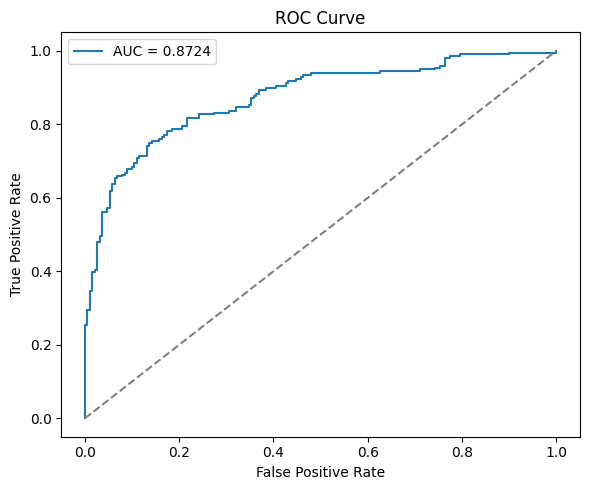

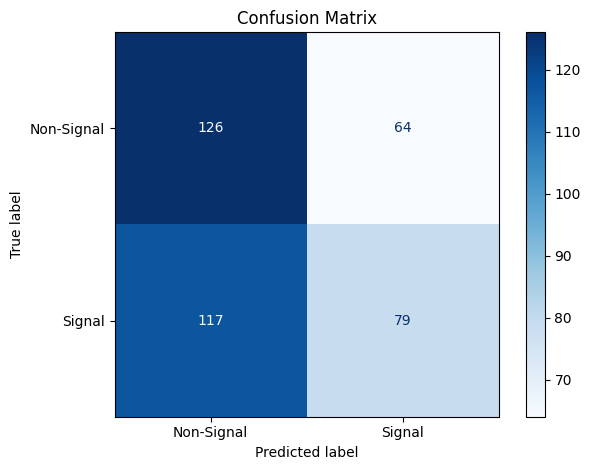

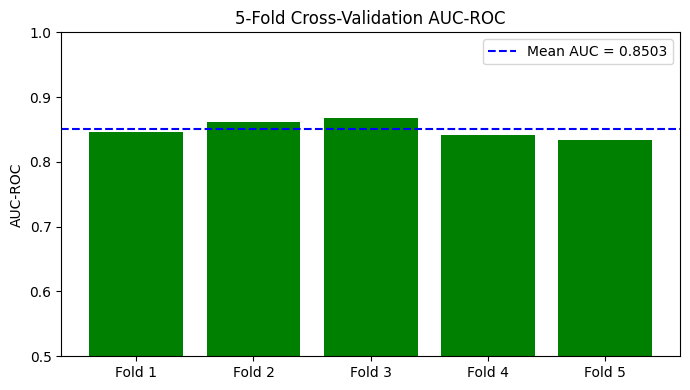

In [18]:

fpr, tpr, _ = roc_curve(y_test, preds)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, preds):.4f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('Data/roc_curve.png', dpi=150)
plt.show()

cm = confusion_matrix(y_test, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Signal','Signal'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('Data/confusion_matrix.png', dpi=150)
plt.show()

folds = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']
aucs  = fold_aucs
plt.figure(figsize=(7,4))
plt.bar(folds, aucs, color=['green' if a > 0.75 else 'red' for a in aucs])
plt.axhline(y=np.mean(aucs), color='blue', linestyle='--', label=f'Mean AUC = {np.mean(aucs):.4f}')
plt.ylim(0.5, 1.0)
plt.ylabel('AUC-ROC')
plt.title('5-Fold Cross-Validation AUC-ROC')
plt.legend()
plt.tight_layout()
plt.savefig('Data/cv_folds.png', dpi=150)
plt.show()

In [16]:
def predict_sequence(seq):
    spaced = ' '.join(seq[:500])
    inputs = tokenizer(spaced, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
        bert_emb = outputs.last_hidden_state[:, 0, :].numpy()

    clean = ''.join([aa for aa in seq if aa in AMINO_ACIDS])
    a = ProteinAnalysis(clean)
    phys = np.array([[
        a.gravy(),
        a.isoelectric_point(),
        a.molecular_weight(),
        a.instability_index(),
        a.aromaticity(),
        a.secondary_structure_fraction()[0]
    ]])
    phys_scaled = scaler.transform(phys)

    x = np.hstack([bert_emb, phys_scaled])
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    model_dl.eval()
    with torch.no_grad():
        prob = model_dl(x_tensor).item()

    label = "Signal Peptide" if prob >= optimal_threshold else "Non-Signal"
    print(f"Sequence    : {seq[:30]}...")
    print(f"Prediction  : {label}")
    

predict_sequence("MKWVTFISLLFLFSSAYSRGVFRR")     

Sequence    : MKWVTFISLLFLFSSAYSRGVFRR...
Prediction  : Signal Peptide
